In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


# In multi class classification jitne output values hoti hai ham utni hi nodes lete in output

# inputs me bhi 28 : 28 hai to inputs me 784 layers ayengi



In [2]:
import tensorflow
from tensorflow import keras
from keras import Sequential
from keras.layers import Dense , Flatten

In [3]:
(X_train,y_train ),(X_test,y_test)=keras.datasets.mnist.load_data()

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [4]:
X_train.shape

(60000, 28, 28)

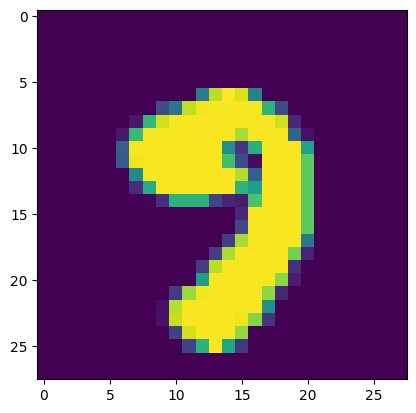

In [5]:
import matplotlib.pyplot as plt
plt.imshow(X_train[6100])

# Input data me jitna kam variations ho utna hi neural networks biases and convergence fast nikalta hai

so ham sab pixels 0-1 me le ayenge

In [6]:
X_train=X_train/255
X_test=X_test/255

In [20]:
model=Sequential()
model.add(Flatten(input_shape=(28,28)))
model.add(Dense(128,activation='relu'))
model.add(Dense(32,activation='relu'))
model.add(Dense(10,activation='softmax'))

/usr/local/lib/python3.12/dist-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


28 & 28 wala data ko hame flatten karna padega 1d me lana padega isiliye ham keras me flatten karke library

In [22]:
model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten_1 (Flatten)             │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │       100,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 32)             │         4,128 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 10)             │           330 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 104,938 (409.91 KB)

 Trainable params: 104,938 (409.91 KB)

 Non-trainable params: 0 (0.00 B)

sparse_categorical_crossentropy me one hot encoding nahi karna padta but in categorical_crossentropy hame pehle one hot encoding karna padta hai uske bad ham use karte it as a loss function

In [38]:
model.compile(loss='sparse_categorical_crossentropy',optimizer='Adam',metrics=['accuracy'])

In [39]:
history = model.fit(X_train,y_train,epochs=10,validation_split=0.2)

Epoch 1/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 10s 6ms/step - accuracy: 0.9969 - loss: 0.0081 - val_accuracy: 0.9749 - val_loss: 0.1610
Epoch 2/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 8s 4ms/step - accuracy: 0.9972 - loss: 0.0086 - val_accuracy: 0.9777 - val_loss: 0.1531
Epoch 3/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 13s 6ms/step - accuracy: 0.9975 - loss: 0.0070 - val_accuracy: 0.9778 - val_loss: 0.1610
Epoch 4/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 12s 8ms/step - accuracy: 0.9978 - loss: 0.0071 - val_accuracy: 0.9761 - val_loss: 0.1657
Epoch 5/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 7s 5ms/step - accuracy: 0.9982 - loss: 0.0058 - val_accuracy: 0.9765 - val_loss: 0.1736
Epoch 6/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 7s 5ms/step - accuracy: 0.9970 - loss: 0.0096 - val_accuracy: 0.9769 - val_loss: 0.1589
Epoch 7/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.9980 - loss: 0.0065 - val_accuracy: 0.9772 - val_loss: 0.1755
Epoch 8/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 8s 5ms/step - accuracy: 0.9976 - loss: 0.0083

In [40]:
 y_pred = model.predict(X_test)


313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step


In [41]:
# lekin hame probability se koi matlab nahi hai hame to wo konsa image hai usses
# matlab hai so ------->

y_pred = y_pred.argmax(axis=1)

In [42]:
from sklearn.metrics import accuracy_score
accuracy_score(y_test,y_pred)

0.9761

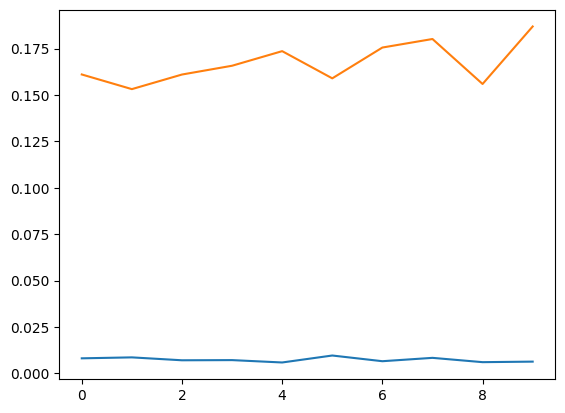

In [45]:
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])

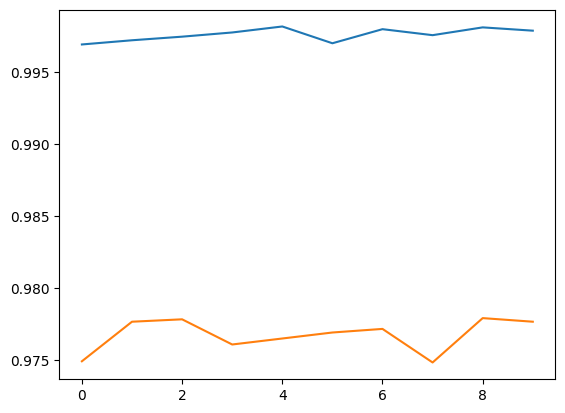

In [44]:
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])